In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

In [3]:
RANDOM_STATE = 42

X, y = make_blobs(n_samples=1000, n_features=2, centers=2, cluster_std=3.8, center_box=(-6, 6), random_state=RANDOM_STATE)

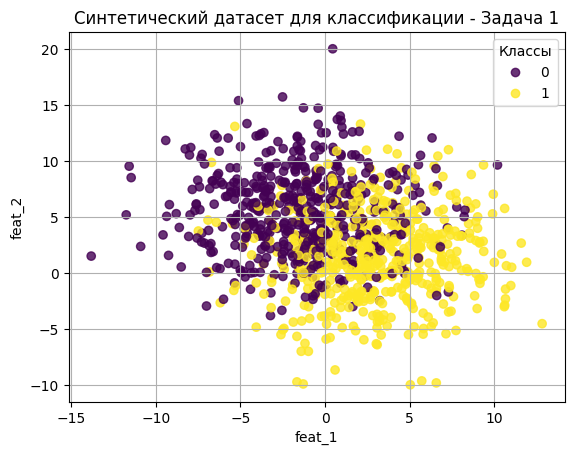

In [4]:
sc = plt.scatter(X[:, 0], X[:, 1], c=y,  alpha=0.8)
plt.title('Синтетический датасет для классификации - Задача 1')
plt.xlabel('feat_1')
plt.ylabel('feat_2')
plt.grid(True)
handles, labels = sc.legend_elements()
plt.legend(handles, labels, title='Классы')
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train, y_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
models = {
    'LogReg': {'model': LogisticRegression(random_state=RANDOM_STATE), 'params': {'C': [0.1, 1, 10]}},
    'SVM': {'model': SVC(random_state=RANDOM_STATE, probability=True), 'params': {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 10]}},
    'Tree': {'model': DecisionTreeClassifier(random_state=RANDOM_STATE), 'params': {'max_depth': [5, 10, 20], 'min_samples_split': [2, 5, 10]}},
    'RandomForest': {'model': RandomForestClassifier(random_state=RANDOM_STATE), 'params': {'n_estimators': [10, 50, 100], 'max_depth': [5, 10, 20]}}
}

In [7]:
def CV_and_evaluate(model, params):
  cv = GridSearchCV(model, param_grid = params, scoring='roc_auc')
  cv.fit(X_train_scaled, y_train)
  y_pred = cv.predict_proba(X_test_scaled)[:, 1]
  roc_auc = roc_auc_score(y_test, y_pred)
  gini = 2 * roc_auc - 1
  return cv.best_params_, gini

In [8]:
results = pd.DataFrame(np.zeros((4, 3)), columns=['Model', 'Best params', 'gini'])

In [9]:
for i, model in enumerate(models):
  res = CV_and_evaluate(models[model]['model'], models[model]['params'])
  results.iloc[i] = model, res[0], round(res[1], 4)

/tmp/ipykernel_1456/1231678046.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'LogReg' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results.iloc[i] = model, res[0], round(res[1], 4)
/tmp/ipykernel_1456/1231678046.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '{'C': 0.1}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results.iloc[i] = model, res[0], round(res[1], 4)


In [10]:
print(results)

          Model                                Best params    gini
0        LogReg                                 {'C': 0.1}  0.8131
1           SVM                   {'C': 10, 'gamma': 0.01}  0.8176
2          Tree  {'max_depth': 5, 'min_samples_split': 10}  0.6884
3  RandomForest      {'max_depth': 5, 'n_estimators': 100}  0.7842


##Выводы
Логистическая регрессия и SVM показали сопоставимые результаты, превосходящие одиночное дерево и случайный лес. Такое превосходство можно объяснить особенностью данного датасета: хотя классы и перекрываются, линейная граница все еще хорошо отделяет один кластер точек от другого. На это также указывает оптимальное значение параметра gamma в SVM (0.01). Также SVM слабо штрафует за ошибки (C=10),что объясняется довольно широкой областью, где классы смешаны.

Одиночное дерево хуже всех справилось с классификацией, так как оно чувствительно к шуму и строит сложные ступенчатые границы. Случайный лес справляется значительно лучше, но все еще уступает линейным моделям.

Хотя лучшее значение коэффициента Джини дала SVM (0.8176), логистическая регрессия дала очень близкий результат(0.8131)  и ее коэффициенты являются хорошо интерпретируемыми. Даже с регуляризацией мы можем делать выводы о направлении влияния коэффициентов (приводит ли увеличение признака к увеличение вероятности целевого класса) и относительной важности признаков. Поэтому логистическая регрессия является оптимальным выбором.